In [21]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

from torch import distributions

Std = 1.0:
	Sample=tensor([1.9298, 1.0478, 1.8185]), LogProbs=tensor([-1.3512, -0.9201, -1.2539]), Entropy=tensor([1.4189, 1.4189, 1.4189])
Std = 0.1:
	Sample=tensor([1.0320, 1.0611, 1.0134]), LogProbs=tensor([1.3323, 1.1972, 1.3747]), Entropy=tensor([-0.8836, -0.8836, -0.8836])
Std = 0.01:
	Sample=tensor([1.0005, 0.9850, 1.0048]), LogProbs=tensor([3.6851, 2.5583, 3.5730]), Entropy=tensor([-3.1862, -3.1862, -3.1862])
Std = 0.001:
	Sample=tensor([0.9997, 1.0002, 0.9996]), LogProbs=tensor([5.9280, 5.9620, 5.9168]), Entropy=tensor([-5.4888, -5.4888, -5.4888])


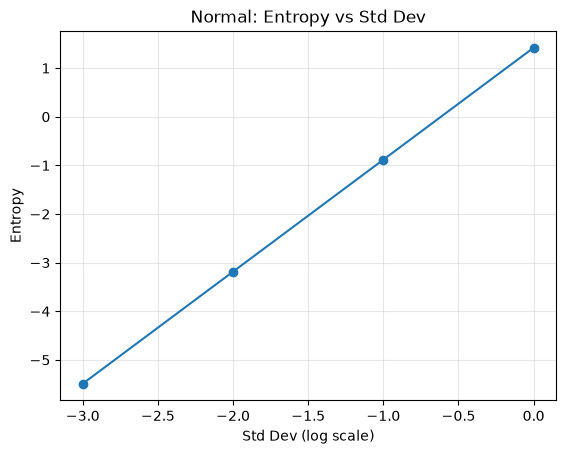

In [ ]:
def test_normal(
    actions: int, mean: float = 1.0, stds: list[float] | None = None, samples: int = 1,
    plot: bool = True
):
    """Samples a batch of `actions` independent Normal(mean, std) variables for each
    std in `stds`, printing the sample, log-prob and entropy so you can see how
    entropy shrinks as std (the spread) shrinks. Returns the list of entropies
    (one per std) and optionally plots entropy vs std.
    """
    if stds is None: stds = [1.0e0, 1.0e-1, 1.0e-2, 1.0e-3]
    assert all([x > 0 for x in stds])

    shape = (actions,)
    mean_t = torch.full(shape, mean)
    entropies = []

    for std_value in stds:
        std_t = torch.full(shape, std_value)
        dist = distributions.Normal(mean_t, std_t)
        sample = dist.sample((samples,)) if samples > 1 else dist.sample()
        entropy = dist.entropy().mean().item()
        entropies.append(entropy)

        print(f"Std = {std_value}:")
        print(f"\tSample={sample}, LogProbs={dist.log_prob(sample)}, Entropy={dist.entropy()}")

    if plot:
        plt.figure()
        plt.plot(np.log10(stds).astype(int), entropies, marker="o")
        # plt.xscale("log")
        plt.xlabel("Std Dev (log scale)")
        plt.ylabel("Entropy")
        plt.title("Normal: Entropy vs Std Dev")
        plt.grid(True, alpha=0.3)
        plt.show()

    return entropies

_ = test_normal(actions=3, mean=1.0)

- An increase in standard deviation should lead to an increase in entropy
- Therefore NEAT PPO algo should aim to reduce entropy in order to reduce standard deviation in Normal policies

Peak action = 7, Sharpness = 1.0
Probs = tensor([5.7661e-04, 1.5674e-03, 4.2606e-03, 1.1582e-02, 3.1482e-02, 8.5577e-02,
        2.3262e-01, 6.3233e-01])
Dilution = 0.0:
	Probs = tensor([5.7661e-04, 1.5674e-03, 4.2606e-03, 1.1582e-02, 3.1482e-02, 8.5577e-02,
        2.3262e-01, 6.3233e-01])
	Sample=tensor([7]), LogProbs=tensor([-0.4583]), Entropy=1.0376317501068115
Dilution = 0.2:
	Probs = tensor([0.0245, 0.1055, 0.1866, 0.0104, 0.1485, 0.1579, 0.3036, 0.6334])
	Sample=tensor([7]), LogProbs=tensor([-0.9079]), Entropy=1.670499324798584
Dilution = 0.4:
	Probs = tensor([0.2678, 0.1923, 0.3006, 0.3629, 0.1014, 0.3177, 0.3298, 0.5205])
	Sample=tensor([0]), LogProbs=tensor([-2.1901]), Entropy=2.001307487487793
Dilution = 0.6000000000000001:
	Probs = tensor([0.3157, 0.1912, 0.2863, 0.0104, 0.1781, 0.2635, 0.3813, 0.2914])
	Sample=tensor([6]), LogProbs=tensor([-1.6156]), Entropy=1.9399710893630981
Dilution = 0.8:
	Probs = tensor([0.5723, 0.5914, 0.0450, 0.1777, 0.2180, 0.4756, 0.7629, 0.8460])

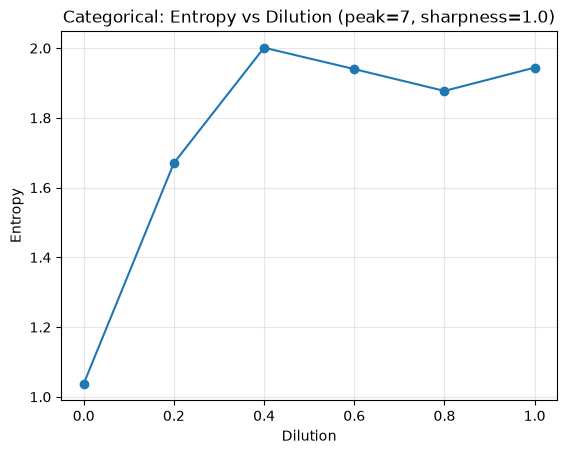

In [45]:
def build_peaked_probs(actions: int, peak_action: int | None = None, sharpness: float = 1.0):
    """Builds a probability distribution over `actions` actions that peaks at
    `peak_action` and decays away from it at a rate controlled by `sharpness`.

    - peak_action=None -> a random action is chosen as the peak (it is returned
      and printed regardless, so it's visible even when picked randomly).
    - sharpness=0       -> uniform / flat distribution ("linear", maximum entropy).
    - sharpness>0       -> exponential decay away from the peak; higher sharpness
      means a sharper spike on the peak action (lower entropy), lower sharpness
      dilutes the exponential shape back towards flat/linear.
    """
    if peak_action is None:
        peak_action = int(torch.randint(0, actions, (1,)).item())
    assert 0 <= peak_action < actions

    idx = torch.arange(actions).float()
    distance = (idx - peak_action).abs()
    logits = -sharpness * distance
    probs = torch.softmax(logits, dim=0)
    return probs, peak_action


def test_categorical(
    actions: int, dilutions: list[float] | None = None, samples: int = 1,
    peak_action: int | None = None, sharpness: float = 1.0, 
    plot: bool = True
):
    assert actions > 1
    if dilutions is None: dilutions = [0.0 + (0.20 * x) for x in range(6)]
    assert all([0 <= x <= 1 for x in dilutions])

    probs, peak_action = build_peaked_probs(actions, peak_action, sharpness)
    print(f"Peak action = {peak_action}, Sharpness = {sharpness}")
    print(f"Probs = {probs}")

    entropies = []
    for value in dilutions:
        print(f"Dilution = {value}:")
        impurity = torch.rand(actions).float()
        true_probs = probs * (1 - value) + impurity * value
        print(f"\tProbs = {true_probs}")
        dist = distributions.Categorical(probs=true_probs)
        sample = dist.sample((samples,))
        entropy = dist.entropy().item()
        entropies.append(entropy)

        print(f"\tSample={sample}, LogProbs={dist.log_prob(sample)}, Entropy={entropy}")

    if plot and len(dilutions) > 1:
        plt.figure()
        plt.plot(dilutions, entropies, marker="o")
        plt.xlabel("Dilution")
        plt.ylabel("Entropy")
        plt.title(f"Categorical: Entropy vs Dilution (peak={peak_action}, sharpness={sharpness})")
        plt.grid(True, alpha=0.3)
        plt.show()

    return entropies

_ = test_categorical(actions=8)

- Reduction of dilution leads some level of reduction of entropy for Categorical distributions

--- Varying sharpness at a fixed peak action (dilution=0, so this is the raw shape) ---
Peak action = 3, Sharpness = 0.0
Probs = tensor([0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250])
Dilution = 0.0:
	Probs = tensor([0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250])
	Sample=tensor([4, 3, 0]), LogProbs=tensor([-2.0794, -2.0794, -2.0794]), Entropy=2.0794413089752197

Peak action = 3, Sharpness = 0.25
Probs = tensor([0.0929, 0.1193, 0.1532, 0.1967, 0.1532, 0.1193, 0.0929, 0.0724])
Dilution = 0.0:
	Probs = tensor([0.0929, 0.1193, 0.1532, 0.1967, 0.1532, 0.1193, 0.0929, 0.0724])
	Sample=tensor([4, 2, 0]), LogProbs=tensor([-1.8760, -1.8760, -2.3760]), Entropy=2.0336380004882812

Peak action = 3, Sharpness = 0.5
Probs = tensor([0.0632, 0.1042, 0.1718, 0.2833, 0.1718, 0.1042, 0.0632, 0.0383])
Dilution = 0.0:
	Probs = tensor([0.0632, 0.1042, 0.1718, 0.2833, 0.1718, 0.1042, 0.0632, 0.0383])
	Sample=tensor([2, 1, 2]), LogProbs=tensor([-1.7614, -2.2614, -1.7614]), 

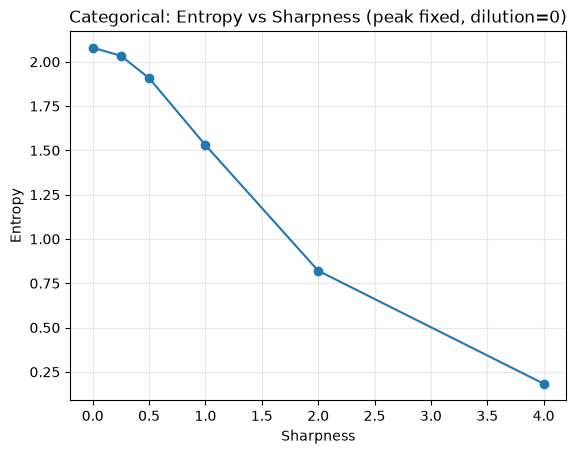

--- Random peak action each call, fixed sharpness ---
Peak action = 3, Sharpness = 1.5
Probs = tensor([0.0071, 0.0317, 0.1421, 0.6367, 0.1421, 0.0317, 0.0071, 0.0016])
Dilution = 0.0:
	Probs = tensor([0.0071, 0.0317, 0.1421, 0.6367, 0.1421, 0.0317, 0.0071, 0.0016])
	Sample=tensor([4, 3, 3]), LogProbs=tensor([-1.9514, -0.4514, -0.4514]), Entropy=1.1409680843353271

Peak action = 3, Sharpness = 1.5
Probs = tensor([0.0071, 0.0317, 0.1421, 0.6367, 0.1421, 0.0317, 0.0071, 0.0016])
Dilution = 0.0:
	Probs = tensor([0.0071, 0.0317, 0.1421, 0.6367, 0.1421, 0.0317, 0.0071, 0.0016])
	Sample=tensor([3, 1, 2]), LogProbs=tensor([-0.4514, -3.4514, -1.9514]), Entropy=1.1409680843353271

Peak action = 3, Sharpness = 1.5
Probs = tensor([0.0071, 0.0317, 0.1421, 0.6367, 0.1421, 0.0317, 0.0071, 0.0016])
Dilution = 0.0:
	Probs = tensor([0.0071, 0.0317, 0.1421, 0.6367, 0.1421, 0.0317, 0.0071, 0.0016])
	Sample=tensor([2, 4, 3]), LogProbs=tensor([-1.9514, -1.9514, -0.4514]), Entropy=1.1409680843353271



In [46]:
print("--- Varying sharpness at a fixed peak action (dilution=0, so this is the raw shape) ---")
sharpness_values = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
sharpness_entropies = []
for sharpness in sharpness_values:
    ent = test_categorical(actions=8, dilutions=[0.0], samples=3, peak_action=3, sharpness=sharpness, plot=False)
    sharpness_entropies.append(ent[0])
    print()

plt.figure()
plt.plot(sharpness_values, sharpness_entropies, marker="o")
plt.xlabel("Sharpness")
plt.ylabel("Entropy")
plt.title("Categorical: Entropy vs Sharpness (peak fixed, dilution=0)")
plt.grid(True, alpha=0.3)
plt.show()

print("--- Random peak action each call, fixed sharpness ---")
for _ in range(3):
    test_categorical(actions=8, dilutions=[0.0], samples=3, sharpness=1.5, plot=False)
    print()

- Sharpness shows stronger correlation to entropy than dilution
- Increase in sharpness leads to an decrease in entropy
- Therefore if you want to increase the sharpness of a given action for a policy then decrease entropy

Dilutions (32) = [0.01, 0.01, 0.02, 0.02, 0.02, 0.02, 0.03, 0.03, 0.04, 0.04, 0.05, 0.06, 0.06, 0.07, 0.09, 0.1, 0.12, 0.13, 0.15, 0.18, 0.21, 0.24, 0.27, 0.32, 0.37, 0.42, 0.49, 0.56, 0.65, 0.75, 0.87, 1.0]
Peak action = 4, Sharpness = 2.0
Probs = tensor([2.5550e-04, 1.8879e-03, 1.3950e-02, 1.0307e-01, 7.6162e-01, 1.0307e-01,
        1.3950e-02, 1.8879e-03, 2.5550e-04, 3.4578e-05, 4.6796e-06, 6.3331e-07,
        8.5710e-08, 1.1600e-08, 1.5698e-09, 2.1245e-10])
Dilution = 0.01:
	Probs = tensor([8.7415e-03, 5.8072e-03, 1.4781e-02, 1.0956e-01, 7.5749e-01, 1.0862e-01,
        1.5979e-02, 9.6626e-03, 9.9929e-03, 7.7047e-05, 4.3841e-03, 8.3405e-03,
        5.6140e-03, 9.1882e-03, 4.0483e-03, 8.5936e-03])
	Sample=tensor([4, 4, 4, 5, 3, 4]), LogProbs=tensor([-0.3555, -0.3555, -0.3555, -2.2977, -2.2891, -0.3555]), Entropy=1.173349380493164
Dilution = 0.01:
	Probs = tensor([7.5483e-03, 1.8917e-03, 2.0048e-02, 1.0279e-01, 7.6149e-01, 1.0992e-01,
        1.7769e-02, 8.0426e-03, 7.4763e-03, 1.4928

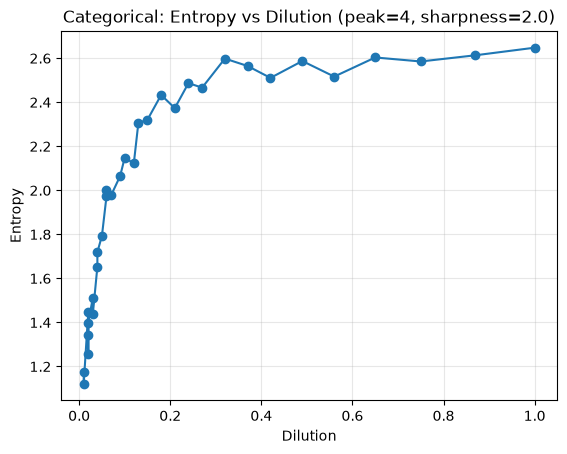

In [56]:
ACTIONS = 16
SAMPLES = 6
D_TOTAL = 32
d_factor = math.exp(math.log(100.) / D_TOTAL)
DILUTIONS = [round(d_factor ** (i + 1) / 100, 2) for i in range(D_TOTAL)]
print(f"Dilutions ({D_TOTAL}) = {DILUTIONS}")

# peak_action=None -> a random peak action is picked (and printed) each call;
# sharpness controls how exponential/peaked (high) vs flat/linear (low, ->0) the
# underlying action distribution is before dilution mixes in uniform noise.
# test_categorical plots entropy vs dilution automatically (plot=True by default).
_ = test_categorical(ACTIONS, DILUTIONS, SAMPLES, peak_action=4, sharpness=2.0)